# Week 8 Unsupervised Learning

## Unsupervised Machine Learning

Unsupervised machine learning is common across wide range of applications. Typical unsupervised learning tasks include clustering, dimension reduction, anomaly detection, and density estimation.


**Resources**

- [Good overview of kmeans using python Kmeans - python](https://jakevdp.github.io/PythonDataScienceHandbook/05.11-k-means.html)

- [Good overview of k-means clustering R-code, so just ignore the code](https://uc-r.github.io/kmeans_clustering)

- [Easy to work with python module](https://github.com/omadson/fuzzy-c-means)

- [Python code for Fuzzy-C-Means](https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_cmeans.html)

- [Step by step implementation of Fuzzy C-Means](https://www.kaggle.com/prateekk94/fuzzy-c-means-clustering-on-iris-dataset)

- [How can you use clustering in images handwritten digits](https://medium.com/datadriveninvestor/k-means-clustering-for-imagery-analysis-56c9976f16b6)

- [DBSCAN explanation and Python Code](https://towardsdatascience.com/dbscan-clustering-explained-97556a2ad556)

## 1.1 Clustering

Clustering is probably the most common unsupervised machine learning algorithm. Widely
used in data analysis tasks (e.g. customers grouping/segmentation), image segmentation, semisupervised machine learning algorithms (when you only have few labelled instances), and so on...
**Definition:** A loose definition of clustering could be “the process of organizing objects into groups whose members are similar in some way”. A cluster is therefore a collection of objects which are “similar” between them and are “dissimilar” to the objects belonging to other clusters. We may or may not have actual words to describe why instances are "similar".

There are different clustering algorithms such as K-means, DBSCAN and other clustering algorithms.

### 1.1.1 k-means
k − means clustering is an algorithm to classify or to group your objects based on attributes/features into K number of groups. Here, K is a positive integer number. The grouping is done by minimizing the sum of squares of distances between data and the corresponding cluster centroid.

**Algorithm:** K means algorithm performs three steps as below until convergence:

- Determine the number of clusters K and assume centre point per cluster

- Determine the centroid coordinates of each cluster

- Determine the distance of each object to the centroids

- Group the objects based on the minimum distance

- Iterate until stable (= no object move group and centroids do not change)

### Example 1
Below is a simple example, we first generate manually some data points, store them in a dataframe
and then using k-means to cluster the data into different groups.


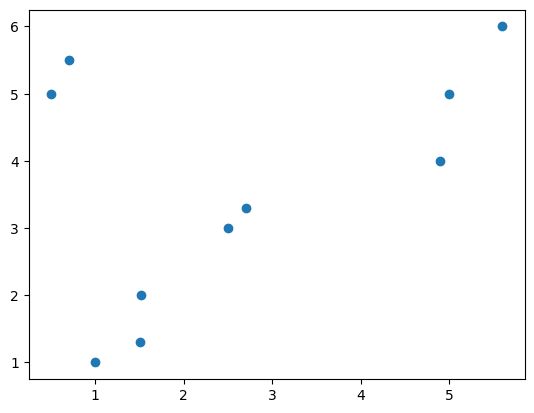

In [1]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# generate some reandom points (manually)
X1 = np.array([0.5,0.7, 1,1.5,1.52,2.5,2.7, 4.9,5,5.6])
X2 = np.array([5,5.5,1,1.3,2,3,3.3,4,5,6])
# plot the data
plt.plot(X1,X2,'o')

In [2]:
# store X1, X2 in a data frame as follows
df = pd.DataFrame({'X1':X1,'X2':X2})
display(df)

,X1,X2
0,0.50,5.0
1,0.70,5.5
2,1.00,1.0
3,1.50,1.3
4,1.52,2.0
5,2.50,3.0
6,2.70,3.3
7,4.90,4.0
8,5.00,5.0
9,5.60,6.0


In [3]:
# cluster into two different clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(df)
# get clusters
kmeans.labels_
# add new label column to your dataframe
df['Labels'] = kmeans.predict(df)


In [4]:
display(df)

,X1,X2,Labels
0,0.50,5.0,0
1,0.70,5.5,0
2,1.00,1.0,0
3,1.50,1.3,0
4,1.52,2.0,0
5,2.50,3.0,0
6,2.70,3.3,0
7,4.90,4.0,1
8,5.00,5.0,1
9,5.60,6.0,1


<Axes: xlabel='X1', ylabel='X2'>

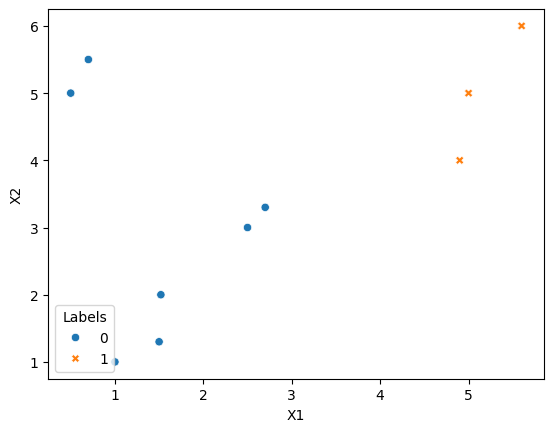

In [5]:
# plot data and map the color of the points to the cluster
sns.scatterplot(data=df, x="X1", y="X2", hue="Labels",style="Labels")

What if you set K to equal 3 in the above example? Looking at the data points, how many clusters do YOU think there should be? What if you set it to that number?

## Example 2

Below is another simple example with synthetic data, here we use the make_blobs function to simulate some data rather than manually creating it. The code below generates 150 data points in the 2D space, representing three different groups / clusters

In [6]:
from sklearn.datasets import make_blobs
# simulate some data
X, y = make_blobs (n_samples = 150,
n_features = 2,
centers = 3,
cluster_std = 0.5,
shuffle = True,
random_state = 0)
# lets store the data in a dataframe
df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})
df.head()

,X1,X2,y
0,2.605097,1.225296,1
1,0.532377,3.313389,0
2,0.802314,4.381962,0
3,0.528537,4.497239,0
4,2.618585,0.357698,1


Plot the blobs to visualise them - your blobs will differ if you use a different random_state.

<Axes: xlabel='X1', ylabel='X2'>

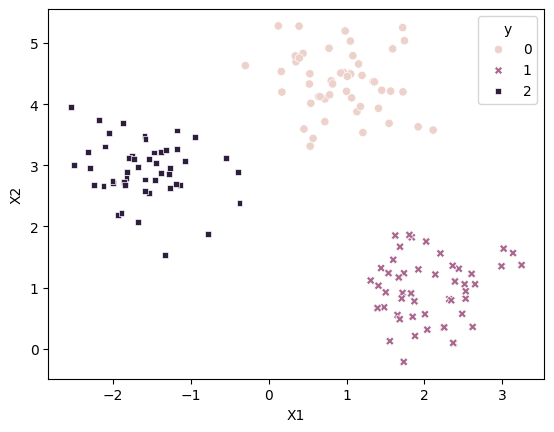

In [7]:

sns.scatterplot(data=df, x="X1", y="X2", hue="y",style="y")

Fit k-means to the data

In [8]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
# for clarity, lets check the clusters
kmeans.labels_

array([1, 2, 2, 2, 1, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 1, 0, 1, 2, 1,
       2, 2, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 2, 0, 0, 2, 1,
       1, 1, 0, 2, 0, 2, 1, 2, 2, 1, 1, 0, 2, 1, 0, 2, 0, 0, 0, 0, 2, 0,
       2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 0, 0, 2, 1, 1, 2, 2, 1, 1, 1, 0,
       0, 1, 1, 2, 1, 2, 1, 2, 0, 0, 1, 1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 2,
       0, 2, 1, 0, 2, 0, 2, 2, 0, 0, 2, 1, 2, 2, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1])

Now add the labels to the original dataframe

In [9]:
df['Cluster'] = kmeans.predict(X)
df.head()

,X1,X2,y,Cluster
0,2.605097,1.225296,1,1
1,0.532377,3.313389,0,2
2,0.802314,4.381962,0,2
3,0.528537,4.497239,0,2
4,2.618585,0.357698,1,1


**Exercise:** Clearly in the above example, we can inspect visually the quality of the cluster as can be seen in the diagram below. Another way is just to check the y label along the Cluster. Notice here, you don’t check if y == Cluster, instead, you want to check that all instances of y ∈ 1 belongs to the same cluster.

Notice that you can use hue to represent the cluster but style to represent the original y value. They might be numerically different, but instances with the same y are also assigned to the same cluster (because of how blobs works). Can you see any incorrect data points?

Text(0, 0.5, 'X2')

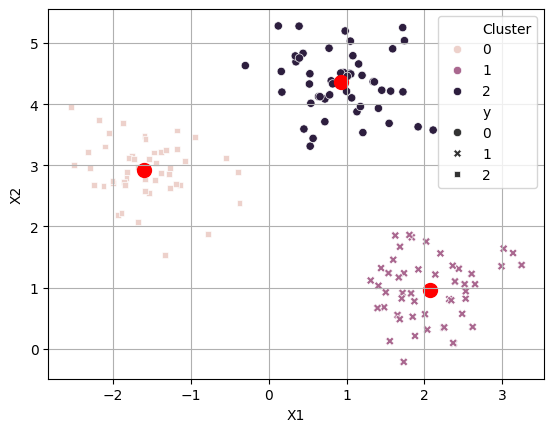

In [10]:
# plot the data and clusters
sns.scatterplot(data=df, x="X1", y="X2", hue="Cluster",style="y")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
s=100, c='red', label = 'Centroids')
plt.grid()
plt.xlabel("X1")
plt.ylabel('X2')

In [11]:
# check clusters centroid
kmeans.cluster_centers_

array([[-1.5947298 ,  2.92236966],
       [ 2.06521743,  0.96137409],
       [ 0.9329651 ,  4.35420712]])

You may want to change the K value to 4 or 2, and see how clustering of the data changes. It
should be noted that one of the limitation of k−means is that you have to set the number of
clusters in advance. The blobs might yet sub-divide into smaller clusters.

Text(0, 0.5, 'X2')

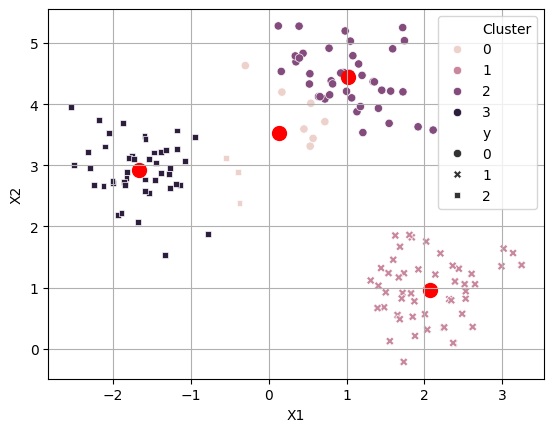

In [22]:
# Optional code for above checking k=4 = would be better in functions
X, y = make_blobs (n_samples = 150,
n_features = 2,
centers = 3,
cluster_std = 0.5,
shuffle = True,
random_state = 0)
# lets store the data in a dataframe
df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})

## Fit the kmeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=0).fit(X)
df['Cluster'] = kmeans.predict(X)

# plot the data and clusters
sns.scatterplot(data=df, x="X1", y="X2", hue="Cluster",style="y")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
s=100, c='red', label = 'Centroids')
plt.grid()
plt.xlabel("X1")
plt.ylabel('X2')

### 1.1.4 Fuzzy C-Means
Unlike k−means Fuzzy C-Means or FCM is considered a soft clustering algorithm. Similar to the
example above, here we use the make_blobs function to simulate some data then using FCM to
cluster it rather than k − means. Notice, that you need to have the required library installed, it you don’t have it in your system, then this can be done using `!pip install fuzzy-c-means`

**Warning** This might not work in the RGU labs

In [ ]:
## Uncomment to install fuzzy-c-means package.
#!pip install fuzzy-c-means

In [14]:
# Source: https://github.com/omadson/fuzzy-c-means
from fcmeans import FCM
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt
from seaborn import scatterplot as scatter
n_bins = 3 # 3 bins for three clusters
centers = [(-5, -5), (0, 0), (5, 5)]
X,y = make_blobs(n_samples=1000, n_features=2, cluster_std=1.0,
centers=centers, shuffle=False, random_state=42)
# two dimensional dataset of 1000 data points
X.shape

(1000, 2)

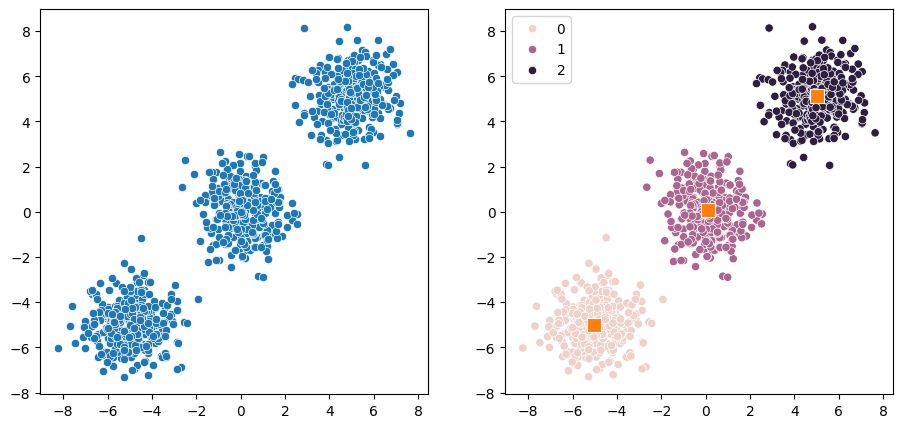

In [20]:
# fit the fuzzy-c-means (3 clusters)
fcm = FCM(n_clusters=3)
fcm.fit(X)
# outputs
fcm_centers = fcm.centers
fcm_labels = fcm.u.argmax(axis=1)
# plot result
%matplotlib inline
f, axes = plt.subplots(1, 2, figsize=(11,5))
scatter(x=X[:,0], y=X[:,1], ax=axes[0])
# plot data with clusters centres
scatter(x=X[:,0], y=X[:,1], ax=axes[1], hue=fcm_labels)
scatter(x=fcm_centers[:,0], y=fcm_centers[:,1], ax=axes[1],marker="s",s=100)
plt.show()

## 1.2 DBSCAN

[The sci-kit learn documentation is a good source on DBSCAN - refers to original papers](https://scikit-learn.org/dev/modules/generated/sklearn.cluster.DBSCAN.html)
From the lecture, DBSCAN is a clustering method that relies on 2 parameters:

- the eta neighbourhood radius and 

- the min-samples required to describe an instance as "core"

This code gives you a chance to explore these.

In [23]:
# Optional code for above checking k=4 = would be better in functions
X, y = make_blobs (n_samples = 150,
n_features = 2,
centers = 3,
cluster_std = 0.5,
shuffle = True,
random_state = 0)
# lets store the data in a dataframe
df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})

You can plot the blobs if you like. We will now use DBSCAN to cluster.

In [25]:
from sklearn.cluster import DBSCAN
import numpy as np

clustering = DBSCAN(eps=3, min_samples=2).fit(df)

In [46]:
labels = clustering.labels_
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 1
Estimated number of noise points: 0


How many clusters were discovered by DBSCAN? What happens if you change the values for eps and min_samples?

## 1.3 Real world sample

[Data from here](https://archive.ics.uci.edu/dataset/476/buddymove+data+set). Retrieve the data file from there and put it somewhere it can be opened. 

The data consists of destination reviews published by 249 people using holidayiq.com. Reviews falling in 6 categories among destinations across South India were considered and the count of reviews in each category for every reviewer (traveler) is captured. 

- Attribute 1 : Unique user id
- Attribute 2 : Number of reviews on stadiums, sports complex, etc.
- Attribute 3 : Number of reviews on religious institutions
- Attribute 4 : Number of reviews on beach, lake, river, etc.
- Attribute 5 : Number of reviews on theatres, exhibitions, etc.
- Attribute 6 : Number of reviews on malls, shopping places, etc.
- Attribute 7 : Number of reviews on parks, picnic spots, etc. 

We want to cluster the data to see if users are similar to each other. If people post similar numbers of reviews for various destinations, then we can target similar adverts to similar people.

In [28]:
# First, read in the file
df = pd.read_csv("buddymove_holidayiq.csv")
display(df)

,User Id,Sports,Religious,Nature,Theatre,Shopping,Picnic
0,User 1,2,77,79,69,68,95
1,User 2,2,62,76,76,69,68
2,User 3,2,50,97,87,50,75
3,User 4,2,68,77,95,76,61
4,User 5,2,98,54,59,95,86
...,...,...,...,...,...,...,...
244,User 245,18,139,148,129,129,168
245,User 246,22,114,228,104,84,168
246,User 247,20,124,178,104,158,174
247,User 248,20,133,149,139,144,213


In [30]:
# Now drop the useless User Id column

df = df.drop("User Id", axis=1)
display(df)

,Sports,Religious,Nature,Theatre,Shopping,Picnic
0,2,77,79,69,68,95
1,2,62,76,76,69,68
2,2,50,97,87,50,75
3,2,68,77,95,76,61
4,2,98,54,59,95,86
...,...,...,...,...,...,...
244,18,139,148,129,129,168
245,22,114,228,104,84,168
246,20,124,178,104,158,174
247,20,133,149,139,144,213


In [33]:
#PCA analysis for easier data viewing
from sklearn.decomposition import PCA
pca_model = PCA(n_components=2)
pca_array = pca_model.fit_transform(df)
pca_df = pd.DataFrame(pca_array)

In [39]:
# rename columns to make them nice
pca_df = pca_df.rename(columns={pca_df.columns[0]: "PCA1"})
pca_df = pca_df.rename(columns={pca_df.columns[1]: "PCA2"})
display(pca_df)

,PCA1,PCA2
0,-76.478514,-39.076470
1,-94.709587,-43.836689
2,-105.023881,-12.923339
3,-85.640237,-42.641062
4,-57.339992,-77.831417
...,...,...
244,54.421421,25.233907
245,17.921215,104.622526
246,67.349089,39.155895
247,83.775336,37.220741


Now, we've just performed PCA without first normalising the dataset. Given that all the columns in the dataset were numbers of reviews (i.e. they all measured the same thing), this might not be necessary. But you might want to add in normalisation to see if it makes any differences.

Let's view the principal components to see if we can see any clusters:

Text(0, 0.5, 'PCA 1')

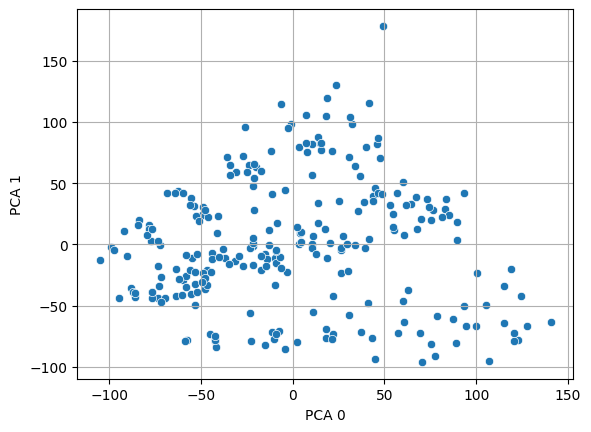

In [40]:
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2")
plt.grid()
plt.xlabel("PCA 0")
plt.ylabel('PCA 1')

Well, maybe there are some clusters. Let's see what k-means finds:

Text(0, 0.5, 'X2')

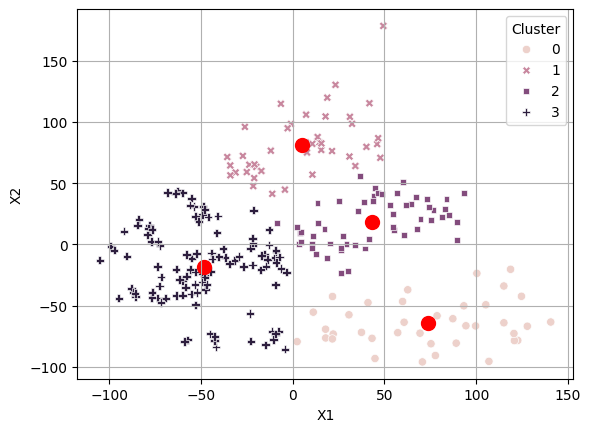

: 

In [ ]:
# Copied and adapted from above
## Fit the kmeans with 3 clusters
kmeans = KMeans(n_clusters=4, random_state=0).fit(pca_df)
pca_df['Cluster'] = kmeans.predict(pca_df)

# plot the data and clusters
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="Cluster",style="Cluster")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
s=100, c='red', label = 'Centroids')
plt.grid()
plt.xlabel("X1")
plt.ylabel('X2')

You could apply the clusters to the original dataframe (before PCA) and see if you can interpret any of them.